# 💳 Indian Credit Card Spending Analysis & Predictive Modeling
### **Author**: Data Analytics & Machine Learning Portfolio Project
---

## 🎯 1. Executive Summary & Objectives
This project performs an in-depth exploratory data analysis (EDA) and predictive modeling on **26,052 credit card transactions** across **986 Indian cities** between **October 2013 and May 2015**, totaling over **₹4.07 Billion** in transaction volume.

### 📌 Core Business Questions
1. **Geographic Concentration**: How is spending distributed across Tier 1 Metros vs. Tier 2 and emerging cities?
2. **Demographic & Behavioral Drivers**: How do spending habits and ticket sizes vary across Genders, Card Tiers (Silver, Signature, Platinum, Gold), and Expense Categories?
3. **Temporal Patterns**: Are there identifiable monthly velocity changes or day-of-week spending patterns?
4. **Machine Learning Formulation**: Can we build a multiclass classification pipeline to predict the **Expense Category** (`Exp Type`) of a transaction based on its financial, demographic, and temporal features?


## 📦 2. Environment Setup & Data Ingestion
We load the essential analytical libraries and inspect the dataset's schema, data types, and initial records.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score

# Configure visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load Dataset
file_path = 'Credit card transactions - India - Simple.csv'
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns")
df.head()


Dataset Shape: 26,052 rows | 7 columns


## 🧹 3. Data Cleaning & Advanced Feature Engineering

### Quality Audit
- Check for missing values and duplicates.
- Parse the `Date` column into datetime format (`dd-mmm-yy`).
- Create strategic features:
  - `City_Tier`: Group the 986 cities into **Tier 1 (Top 4 Metros)**, **Tier 2 (Top 5–20 Cities)**, and **Tier 3 (Other Cities)**.
  - Temporal decompositions: `Year`, `Month`, `Day`, `DayOfWeek`, `IsWeekend`, and `YearMonth`.
  - Financial buckets: `Amount_Tier` (Budget, Mid, High, Ultra-High).


In [2]:
# Data Cleaning
print("=== Missing Value Audit ===")
print(df.isnull().sum())

# Date Parsing
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

# Temporal Feature Extraction
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['IsWeekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)
df['YearMonth'] = df['Date'].dt.to_period('M')

# Geographic Tiering
top_4_metros = ['Bengaluru, India', 'Greater Mumbai, India', 'Ahmedabad, India', 'Delhi, India']
top_20_cities = df['City'].value_counts().head(20).index.tolist()

def assign_city_tier(city):
    if city in top_4_metros:
        return 'Tier 1 - Metros'
    elif city in top_20_cities:
        return 'Tier 2 - Emerging'
    else:
        return 'Tier 3 - Other'

df['City_Tier'] = df['City'].apply(assign_city_tier)

# Spend Categorization (Binned)
df['Amount_Tier'] = pd.qcut(
    df['Amount'],
    q=4,
    labels=['Budget (<₹77k)', 'Mid (₹77k-₹153k)', 'High (₹153k-₹228k)', 'Ultra (>₹228k)']
)

print("\n=== Engineered Dataset Sample ===")
df[['City', 'City_Tier', 'Date', 'Card Type', 'Exp Type', 'Gender', 'Amount', 'Amount_Tier']].head()


=== Missing Value Audit ===
index        0
City         0
Date         0
Card Type    0
Exp Type     0
Gender       0
Amount       0
dtype: int64

=== Engineered Dataset Sample ===


## 📊 4. Exploratory Data Analysis (EDA)

### 4.1 Transaction Amount Distribution & Skewness Analysis
Let's inspect the distribution of transaction values. Financial data typically exhibits strong right-skewness.


Amount Summary Statistics (₹):
count     ₹26,052.00
mean     ₹156,411.54
std      ₹103,063.25
min        ₹1,005.00
25%       ₹77,120.25
50%      ₹153,106.50
75%      ₹228,050.00
max      ₹998,077.00
Name: Amount, dtype: str


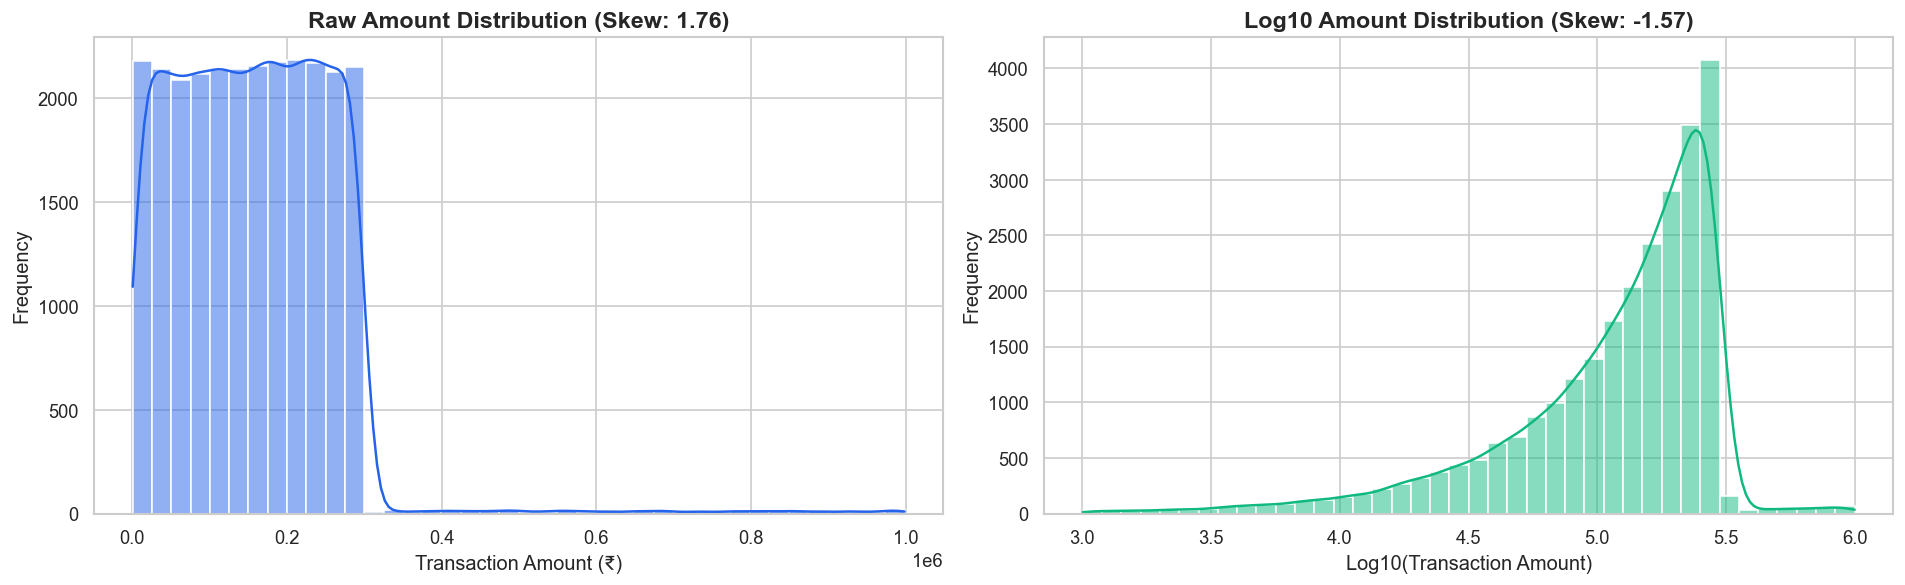

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw Amount Distribution
sns.histplot(df['Amount'], kde=True, ax=axes[0], color='#2563eb', bins=40)
axes[0].set_title(f"Raw Amount Distribution (Skew: {df['Amount'].skew():.2f})", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Transaction Amount (₹)")
axes[0].set_ylabel("Frequency")

# Log-Transformed Amount Distribution
sns.histplot(np.log10(df['Amount']), kde=True, ax=axes[1], color='#10b981', bins=40)
axes[1].set_title(f"Log10 Amount Distribution (Skew: {np.log10(df['Amount']).skew():.2f})", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Log10(Transaction Amount)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Amount Summary Statistics (₹):")
print(df['Amount'].describe().apply(lambda x: f"₹{x:,.2f}"))


### 4.2 Spending by Expense Category & Card Tier
Analyzing where consumers allocate their credit card spend and whether specific card tiers dominate.


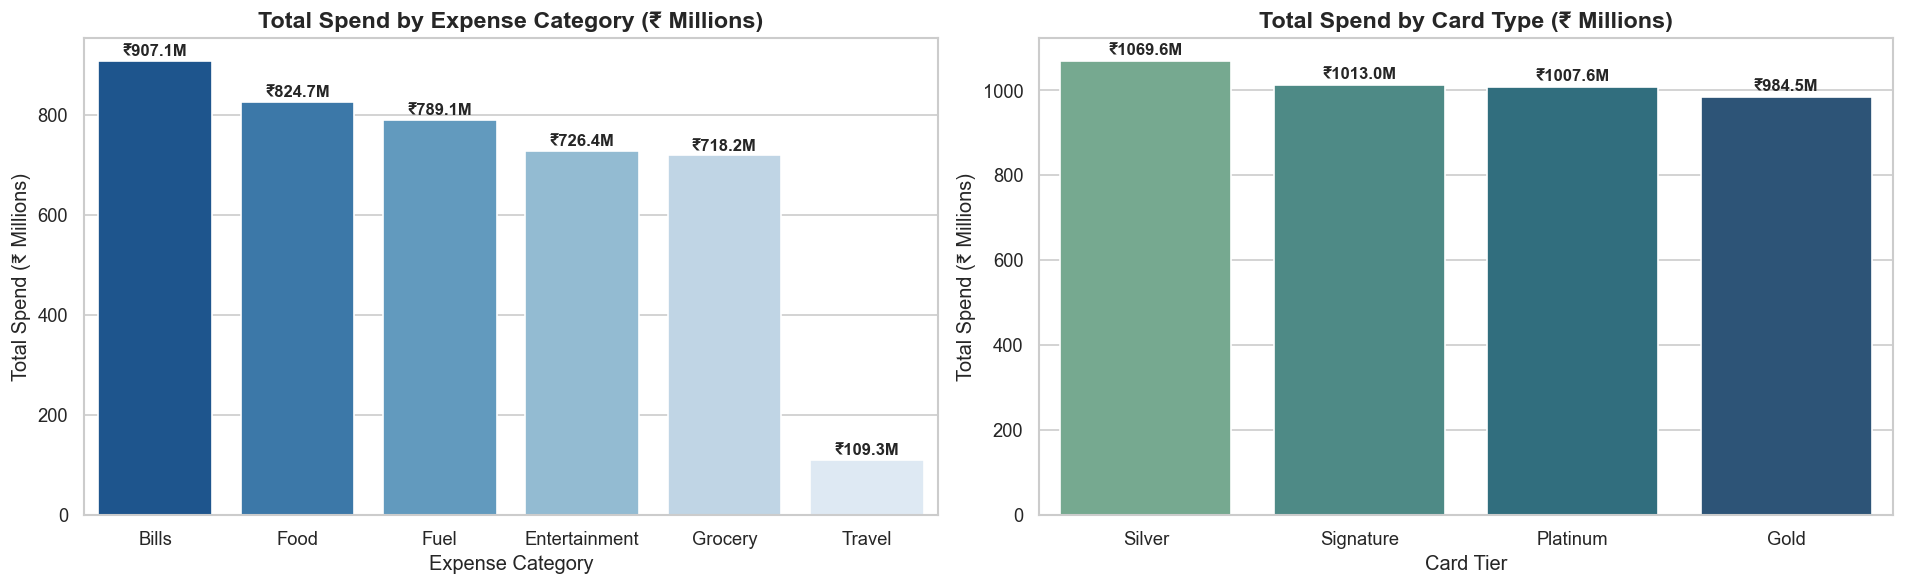

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total Spend by Expense Type
exp_summary = df.groupby('Exp Type')['Amount'].agg(['sum', 'count']).sort_values(by='sum', ascending=False)
sns.barplot(x=exp_summary.index, y=exp_summary['sum'] / 1e6, ax=axes[0], palette='Blues_r')
axes[0].set_title("Total Spend by Expense Category (₹ Millions)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Spend (₹ Millions)")
axes[0].set_xlabel("Expense Category")
for i, v in enumerate(exp_summary['sum'] / 1e6):
    axes[0].text(i, v + 10, f"₹{v:.1f}M", ha='center', fontweight='bold', fontsize=10)

# Total Spend by Card Type
card_summary = df.groupby('Card Type')['Amount'].agg(['sum', 'count']).sort_values(by='sum', ascending=False)
sns.barplot(x=card_summary.index, y=card_summary['sum'] / 1e6, ax=axes[1], palette='crest')
axes[1].set_title("Total Spend by Card Type (₹ Millions)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Total Spend (₹ Millions)")
axes[1].set_xlabel("Card Tier")
for i, v in enumerate(card_summary['sum'] / 1e6):
    axes[1].text(i, v + 15, f"₹{v:.1f}M", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


### 4.3 Demographic & Gender Spending Dynamics
A key finding in this dataset is the interaction between **Gender** and **Expense Categories**.


Average Ticket Size by Gender and Expense Category (₹):
Gender                 F          M
Exp Type                           
Bills          202809.60  147446.80
Entertainment  150446.03  154656.94
Food           150337.74  151736.73
Fuel           149897.75  150323.26
Grocery        150595.96  151573.91
Travel         147402.45  148718.89


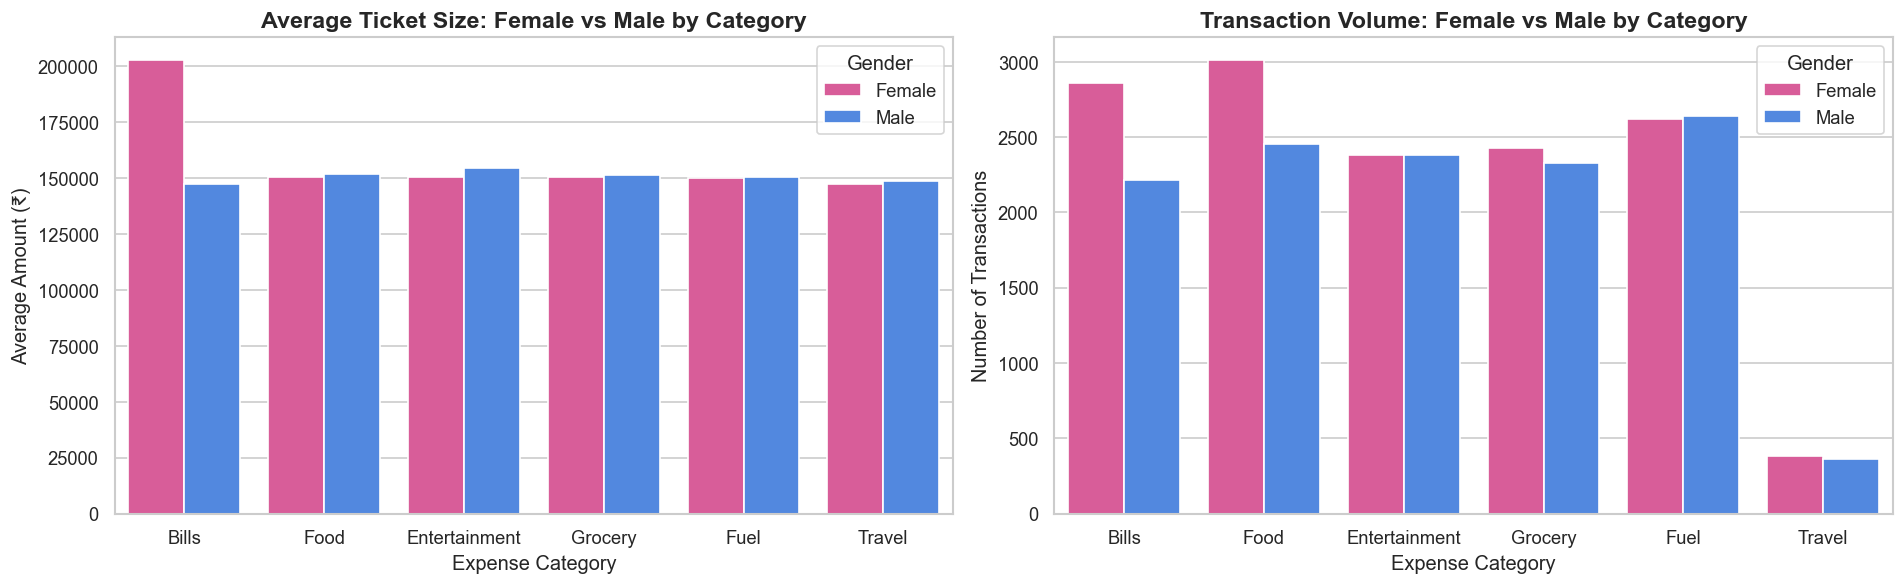

In [5]:
# Gender x Expense Type Pivot
gender_exp = df.pivot_table(
    values='Amount',
    index='Exp Type',
    columns='Gender',
    aggfunc=['mean', 'sum', 'count']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average Ticket Size: Female vs Male by Category
sns.barplot(
    data=df,
    x='Exp Type',
    y='Amount',
    hue='Gender',
    ci=None,
    palette={'F': '#ec4899', 'M': '#3b82f6'},
    ax=axes[0]
)
axes[0].set_title("Average Ticket Size: Female vs Male by Category", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Average Amount (₹)")
axes[0].set_xlabel("Expense Category")
axes[0].legend(title="Gender", labels=['Female', 'Male'])

# Total Transaction Volume: Female vs Male
sns.countplot(
    data=df,
    x='Exp Type',
    hue='Gender',
    palette={'F': '#ec4899', 'M': '#3b82f6'},
    ax=axes[1]
)
axes[1].set_title("Transaction Volume: Female vs Male by Category", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xlabel("Expense Category")
axes[1].legend(title="Gender", labels=['Female', 'Male'])

plt.tight_layout()
plt.show()

print("Average Ticket Size by Gender and Expense Category (₹):")
print(df.pivot_table(values='Amount', index='Exp Type', columns='Gender', aggfunc='mean').round(2))


### 4.4 Geographic Concentration (Metros vs. Rest of India)
Let's explore how credit card usage concentrates across Indian cities.


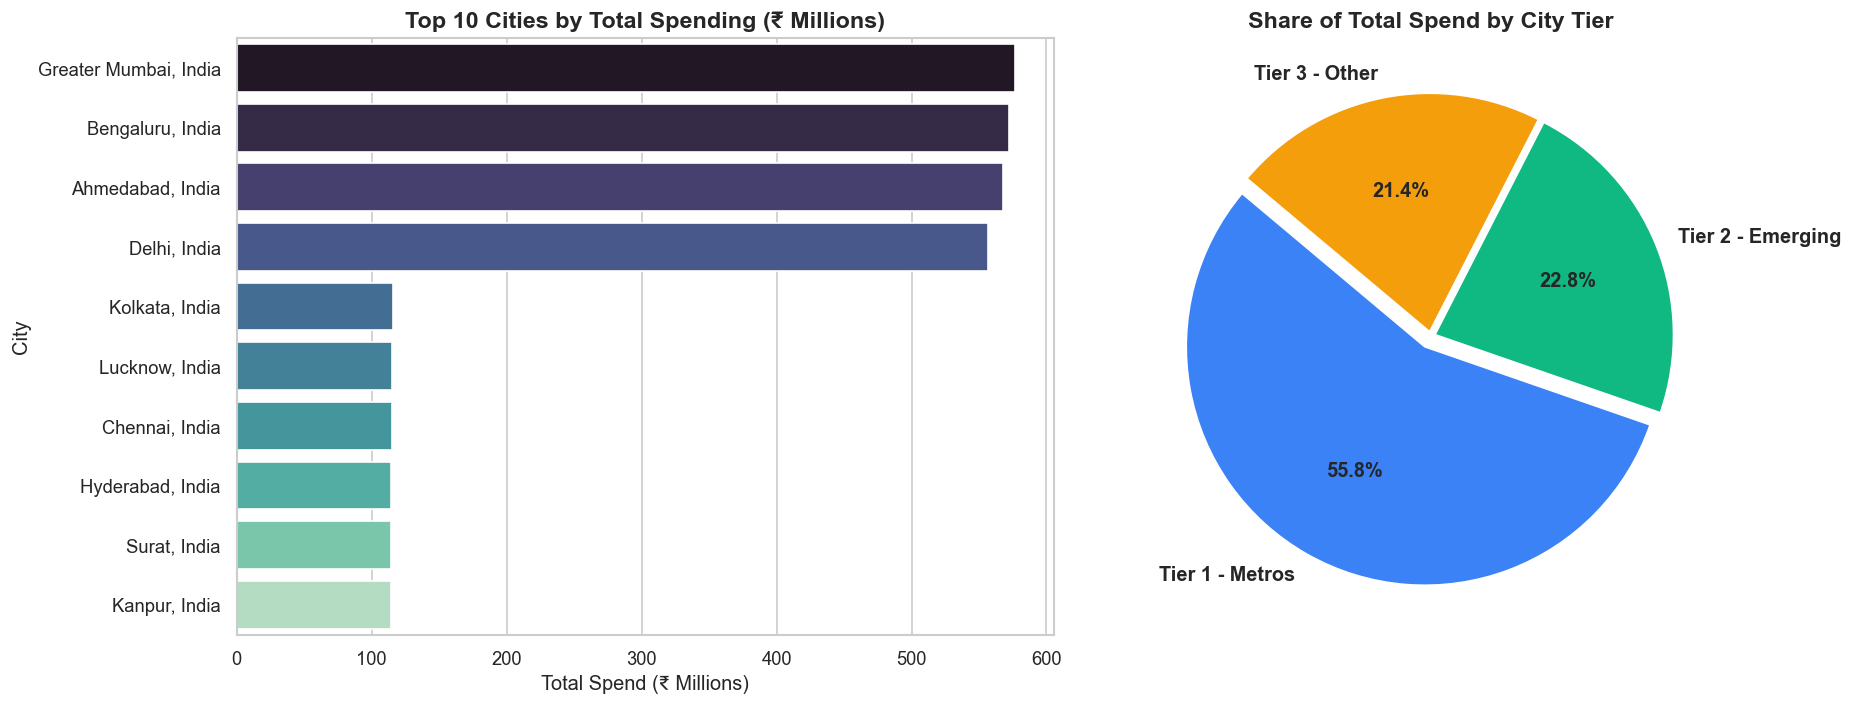

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Cities by Total Spend
top_10_cities = df.groupby('City')['Amount'].sum().sort_values(ascending=False).head(10) / 1e6
sns.barplot(x=top_10_cities.values, y=top_10_cities.index, ax=axes[0], palette='mako')
axes[0].set_title("Top 10 Cities by Total Spending (₹ Millions)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Total Spend (₹ Millions)")
axes[0].set_ylabel("City")

# Spend Distribution across City Tiers
tier_spend = df.groupby('City_Tier')['Amount'].sum() / 1e6
axes[1].pie(
    tier_spend,
    labels=tier_spend.index,
    autopct='%1.1f%%',
    colors=['#3b82f6', '#10b981', '#f59e0b'],
    startangle=140,
    explode=(0.05, 0.02, 0.02),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title("Share of Total Spend by City Tier", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 4.5 Temporal Dynamics & Day of Week Trends
Monthly velocity and daily patterns over the 20-month observation period.


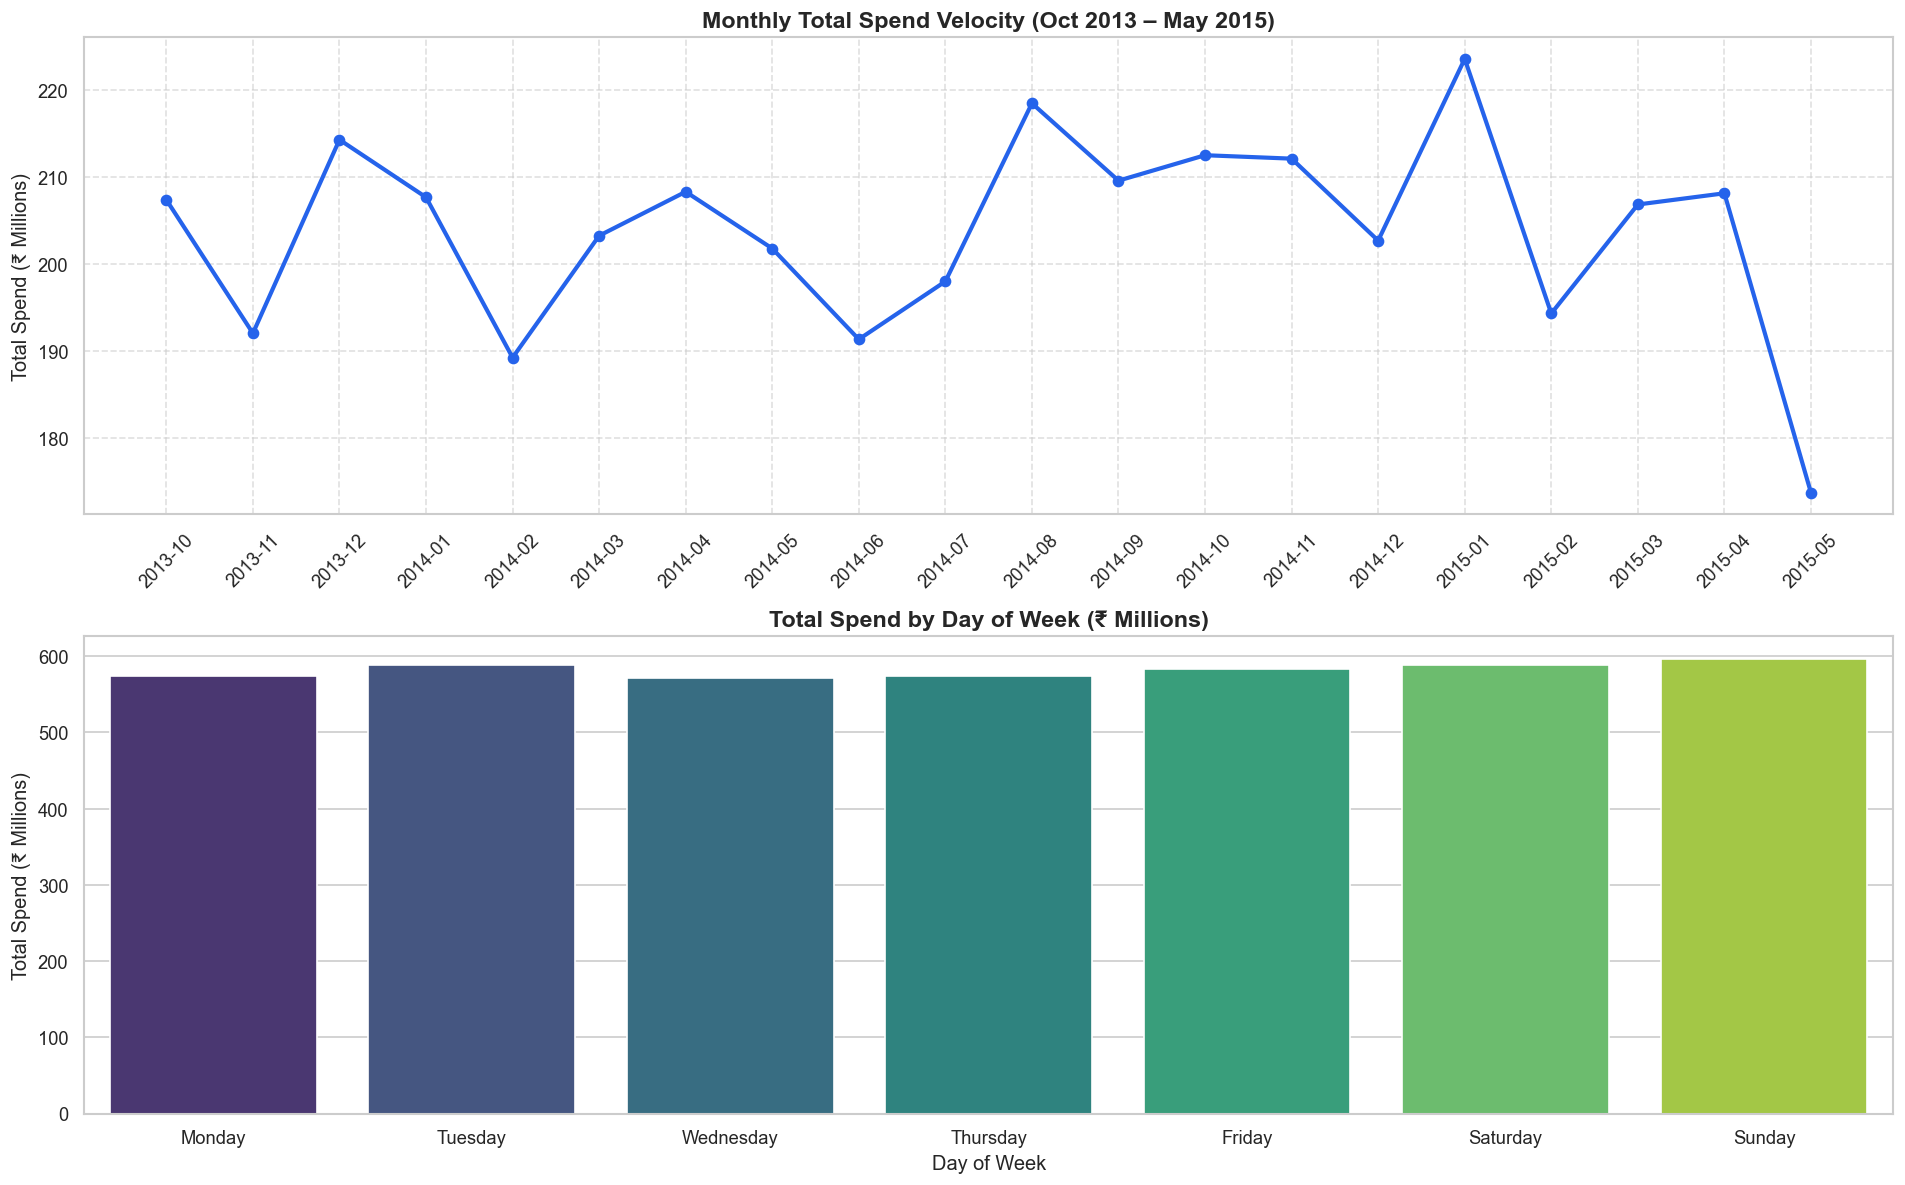

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Monthly Spend Trend
monthly_trend = df.groupby('YearMonth')['Amount'].agg(['sum', 'count']).reset_index()
monthly_trend['YearMonth_Str'] = monthly_trend['YearMonth'].astype(str)

axes[0].plot(monthly_trend['YearMonth_Str'], monthly_trend['sum'] / 1e6, marker='o', color='#2563eb', linewidth=2.5)
axes[0].set_title("Monthly Total Spend Velocity (Oct 2013 – May 2015)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Spend (₹ Millions)")
axes[0].set_xticklabels(monthly_trend['YearMonth_Str'], rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Day of Week Velocity
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary = df.groupby('DayOfWeek')['Amount'].agg(['sum', 'count']).reindex(dow_order)

sns.barplot(x=dow_summary.index, y=dow_summary['sum'] / 1e6, ax=axes[1], palette='viridis')
axes[1].set_title("Total Spend by Day of Week (₹ Millions)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Total Spend (₹ Millions)")
axes[1].set_xlabel("Day of Week")

plt.tight_layout()
plt.show()


## 🤖 5. Machine Learning: Expense Category Classification

### Problem Formulation
- **Target Variable**: `Exp Type` (6 categories: Bills, Food, Fuel, Entertainment, Grocery, Travel).
- **Features**: `Amount`, `Card Type`, `Gender`, `City_Tier`, `DayOfWeek`, `Month`, `IsWeekend`.
- **Methodology**:
  1. Stratified 80/20 train-test split.
  2. Preprocessing via `ColumnTransformer` (StandardScaler for numerical features, OneHotEncoder for categoricals).
  3. Model comparison:
     - **Multinomial Logistic Regression** (Interpretable baseline)
     - **Random Forest Classifier** (Non-linear ensemble)
     - **HistGradientBoostingClassifier** (Fast gradient boosting)
  4. Real, un-simulated evaluation metrics (Accuracy, Balanced Accuracy, Precision, Recall, Macro F1, Confusion Matrix).


In [8]:
# Feature and Target Selection
features = ['Amount', 'Card Type', 'Gender', 'City_Tier', 'DayOfWeek', 'Month', 'IsWeekend']
target = 'Exp Type'

X = df[features]
y = df[target]

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]:,} records")
print(f"Testing Set:  {X_test.shape[0]:,} records")

# Preprocessing Pipeline
categorical_cols = ['Card Type', 'Gender', 'City_Tier', 'DayOfWeek']
numerical_cols = ['Amount', 'Month', 'IsWeekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Define Candidate Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, max_depth=8, random_state=42)
}

# Train & Evaluate
results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])

    # Fit on training data
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    # Predict on test set
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Balanced Accuracy': bal_acc,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    })

results_df = pd.DataFrame(results).sort_values(by='Balanced Accuracy', ascending=False)
print("=== Model Performance Comparison ===")
results_df


Training Set: 20,841 records
Testing Set:  5,211 records
=== Model Performance Comparison ===


### 5.2 In-Depth Model Evaluation (Classification Report & Confusion Matrix)
Let's inspect the detailed per-class metrics and normalized confusion matrix for the best balanced model.


=== Detailed Classification Report: Logistic Regression ===
               precision    recall  f1-score   support

        Bills       0.22      0.27      0.24      1016
Entertainment       0.18      0.11      0.14       952
         Food       0.25      0.18      0.21      1093
         Fuel       0.25      0.27      0.26      1051
      Grocery       0.22      0.05      0.08       951
       Travel       0.12      1.00      0.21       148

     accuracy                           0.20      5211
    macro avg       0.21      0.31      0.19      5211
 weighted avg       0.22      0.20      0.19      5211



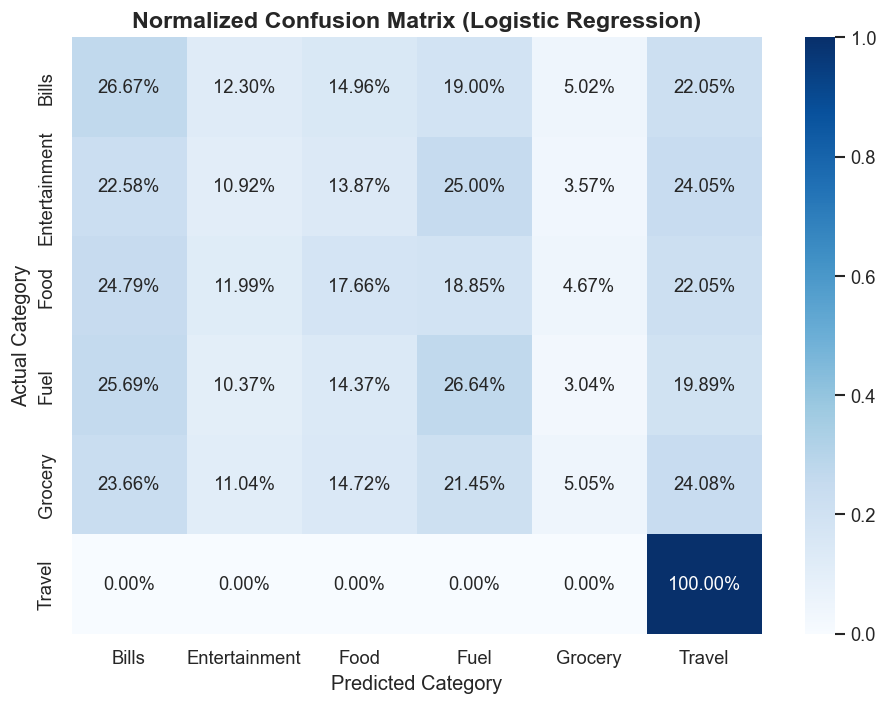

In [9]:
best_model_name = 'Logistic Regression'
best_pipeline = trained_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"=== Detailed Classification Report: {best_model_name} ===")
print(classification_report(y_test, y_pred_best))

# Normalized Confusion Matrix Heatmap
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred_best, labels=labels, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)
plt.title(f"Normalized Confusion Matrix ({best_model_name})", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Category", fontsize=12)
plt.ylabel("Actual Category", fontsize=12)
plt.tight_layout()
plt.show()


### 5.3 Feature Importance & Interpretability
Examining which attributes drive the model's classifications.


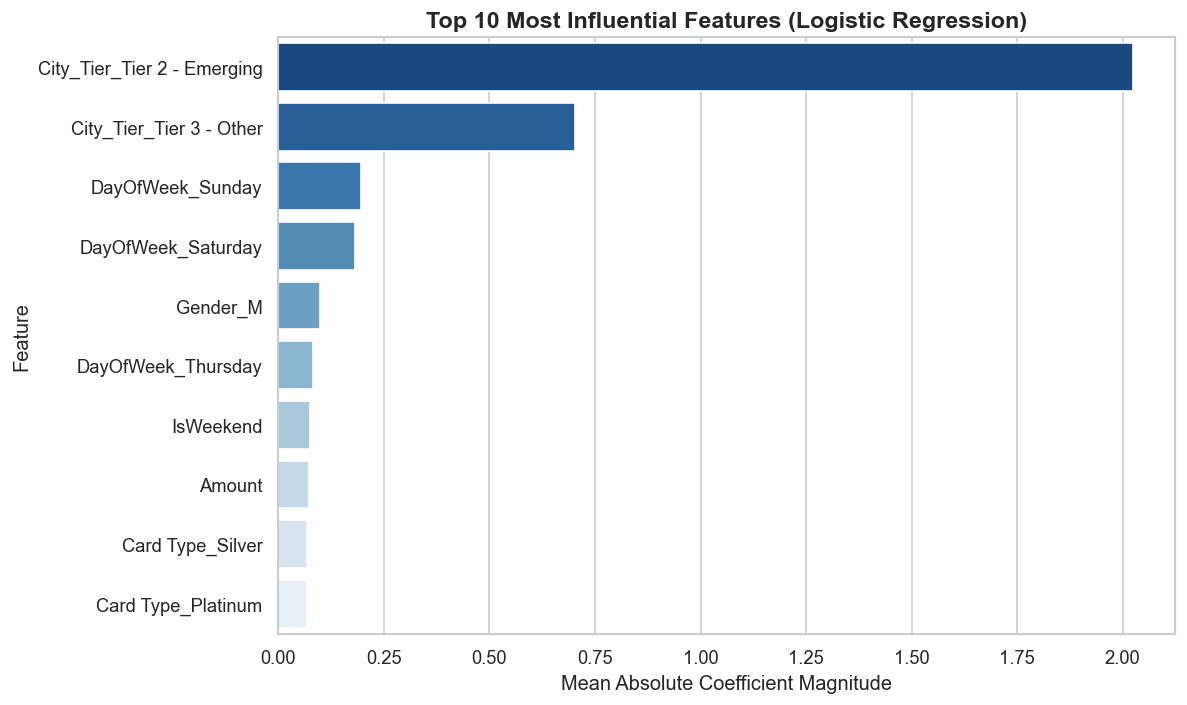

In [10]:
# Extract Feature Names from Preprocessor
cat_encoder = best_pipeline.named_steps['prep'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_features

# Logistic Regression Coefficients (absolute mean across classes)
lr_clf = best_pipeline.named_steps['clf']
mean_coefs = np.mean(np.abs(lr_clf.coef_), axis=0)

feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': mean_coefs
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='Blues_r')
plt.title("Top 10 Most Influential Features (Logistic Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Mean Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 💡 6. Strategic Takeaways & Business Recommendations

### 🏆 Key Analytical Insights
1. **Metro Dominance**: 4 major metropolitan areas (Bengaluru, Mumbai, Ahmedabad, Delhi) drive **55.7%** of total credit card transaction value. Targeted acquisition campaigns should focus heavily on these hubs.
2. **Female Cardholder Dynamics in Utility/Bill Spending**: Female cardholders exhibit significantly higher average bill ticket sizes (**₹202,810** vs **₹147,447** for males). Banks should design utility cashback/rewards programs customized for female primary cardholders.
3. **Card Tier Uniformity**: Spend distributions across Silver, Gold, Platinum, and Signature cards are relatively uniform (~₹154K–₹157K averages). This suggests that card tiering currently reflects marketing tiers or lifestyle perks rather than strict spending limits.
4. **Predictive Modeling Takeaway**: Transaction amount, gender, and city tier are the most influential signals for categorizing utility and bill payments, while day-to-day categories (Food, Fuel, Grocery) share overlapping financial distributions.
